# Physics-Informed Neural Network (PINN) for a Forward Problem with Data

This notebook demonstrates how to solve a forward problem using a PINN where, in addition to the governing PDE, we also have some scattered data points available within the domain. We will be solving the 1D heat equation.

## 1. Problem Setup

We solve the 1D heat equation:
$$ \frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$
with the following conditions:
- **Domain:** $x \in [0, 1]$ and $t \in [0, 1]$
- **Initial Condition (IC):** $u(x, 0) = \sin(\pi x)$
- **Boundary Conditions (BC):** $u(0, t) = 0$ and $u(1, t) = 0$
- **Thermal Diffusivity:** $\alpha = 1/\pi^2$
- **Additional Data:** We will generate some synthetic noisy data points from the analytical solution and use them in the training process.

## 2. Implementation

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Define the Neural Network (PINN)

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),  # Input: (x, t), Output: u(x,t)
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x, t):
        # Concatenate x and t as input to the network
        inputs = torch.cat((x, t), dim=1)
        return self.net(inputs)

### Analytical Solution (for generating data and comparison)

In [3]:
def u_analytical(x, t, alpha):
    return torch.exp(-alpha * (np.pi**2) * t) * torch.sin(np.pi * x)

### Generate Training Data and Collocation Points

In [4]:
# Domain: x in [0, 1], t in [0, 1]
num_pde_points = 10000
num_ic_points = 200
num_bc_points = 200
num_data_points = 50 # Number of synthetic data points

# PDE collocation points (randomly sampled within the domain)
x_pde = torch.rand(num_pde_points, 1, requires_grad=True)
t_pde = torch.rand(num_pde_points, 1, requires_grad=True)

# Initial condition points (t=0)
x_ic = torch.rand(num_ic_points, 1)
t_ic = torch.zeros(num_ic_points, 1)
u_ic_exact = u_analytical(x_ic, t_ic, alpha=1/(np.pi**2))

# Boundary condition points (x=0 and x=1)
# x=0 boundary
x_bc0 = torch.zeros(num_bc_points, 1)
t_bc0 = torch.rand(num_bc_points, 1)
u_bc0_exact = u_analytical(x_bc0, t_bc0, alpha=1/(np.pi**2))

# x=1 boundary
x_bc1 = torch.ones(num_bc_points, 1)
t_bc1 = torch.rand(num_bc_points, 1)
u_bc1_exact = u_analytical(x_bc1, t_bc1, alpha=1/(np.pi**2))

# Synthetic Data points (randomly sampled within the domain)
x_data = torch.rand(num_data_points, 1)
t_data = torch.rand(num_data_points, 1)
u_data_exact = u_analytical(x_data, t_data, alpha=1/(np.pi**2))
# Add some noise to simulate real-world data
u_data_noisy = u_data_exact + 0.05 * torch.randn_like(u_data_exact)

### Define Loss Functions
The total loss is a weighted sum of four components:
$$ L = \lambda_{pde} L_{PDE} + \lambda_{ic} L_{IC} + \lambda_{bc} L_{BC} + \lambda_{data} L_{data} $$

In [5]:
def pde_loss_fn(model, x, t, alpha):
    u = model(x, t)

    # Compute derivatives using autograd
    # du/dt
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    
    # du/dx
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    
    # d^2u/dx^2
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    # Residual of the PDE: du/dt - alpha * d^2u/dx^2 = 0
    pde_residual = u_t - alpha * u_xx
    return torch.mean(pde_residual**2)

def ic_loss_fn(model, x_ic, t_ic, u_ic_exact):
    u_pred_ic = model(x_ic, t_ic)
    return torch.mean((u_pred_ic - u_ic_exact)**2)

def bc_loss_fn(model, x_bc, t_bc, u_bc_exact):
    u_pred_bc = model(x_bc, t_bc)
    return torch.mean((u_pred_bc - u_bc_exact)**2)

def data_loss_fn(model, x_data, t_data, u_data_target):
    u_pred_data = model(x_data, t_data)
    return torch.mean((u_pred_data - u_data_target)**2)

### Initialize Model and Optimizer

In [6]:
pinn_model = PINN()
optimizer = torch.optim.Adam(pinn_model.parameters(), lr=0.001)
epochs = 10000
alpha_val = 1 / (np.pi**2) # Thermal diffusivity

# Weights for different loss components
lambda_pde = 1.0
lambda_ic = 10.0
lambda_bc = 10.0
lambda_data = 100.0 # Give higher weight to data points

### Training Loop

In [7]:
print("Starting PINN training...")
for epoch in range(epochs):
    optimizer.zero_grad()

    # Calculate PDE loss
    pde_loss = pde_loss_fn(pinn_model, x_pde, t_pde, alpha_val)

    # Calculate Initial Condition loss
    ic_loss = ic_loss_fn(pinn_model, x_ic, t_ic, u_ic_exact)

    # Calculate Boundary Condition loss
    bc_loss_0 = bc_loss_fn(pinn_model, x_bc0, t_bc0, u_bc0_exact)
    bc_loss_1 = bc_loss_fn(pinn_model, x_bc1, t_bc1, u_bc1_exact)
    bc_loss = bc_loss_0 + bc_loss_1

    # Calculate Data loss
    data_loss = data_loss_fn(pinn_model, x_data, t_data, u_data_noisy)

    # Total loss
    total_loss = (lambda_pde * pde_loss + lambda_ic * ic_loss + lambda_bc * bc_loss + lambda_data * data_loss)

    total_loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Total Loss: {total_loss.item():.6f}, "
              f"PDE Loss: {pde_loss.item():.6f}, IC Loss: {ic_loss.item():.6f}, "
              f"BC Loss: {bc_loss.item():.6f}, Data Loss: {data_loss.item():.6f}")

print("Training complete!")

Starting PINN training...
Epoch 1000/10000, Total Loss: 0.166050, PDE Loss: 0.011475, IC Loss: 0.000111, BC Loss: 0.000192, Data Loss: 0.001515
Epoch 2000/10000, Total Loss: 0.161095, PDE Loss: 0.008595, IC Loss: 0.000181, BC Loss: 0.000159, Data Loss: 0.001491
Epoch 3000/10000, Total Loss: 0.157522, PDE Loss: 0.008038, IC Loss: 0.000254, BC Loss: 0.000219, Data Loss: 0.001447
Epoch 4000/10000, Total Loss: 0.154362, PDE Loss: 0.008426, IC Loss: 0.000326, BC Loss: 0.000262, Data Loss: 0.001401
Epoch 5000/10000, Total Loss: 0.152308, PDE Loss: 0.009390, IC Loss: 0.000367, BC Loss: 0.000287, Data Loss: 0.001364
Epoch 6000/10000, Total Loss: 0.150155, PDE Loss: 0.010510, IC Loss: 0.000371, BC Loss: 0.000301, Data Loss: 0.001329
Epoch 7000/10000, Total Loss: 0.147933, PDE Loss: 0.012062, IC Loss: 0.000355, BC Loss: 0.000283, Data Loss: 0.001295
Epoch 8000/10000, Total Loss: 0.146247, PDE Loss: 0.013436, IC Loss: 0.000337, BC Loss: 0.000275, Data Loss: 0.001267
Epoch 9000/10000, Total Loss: 

### Visualization and Evaluation

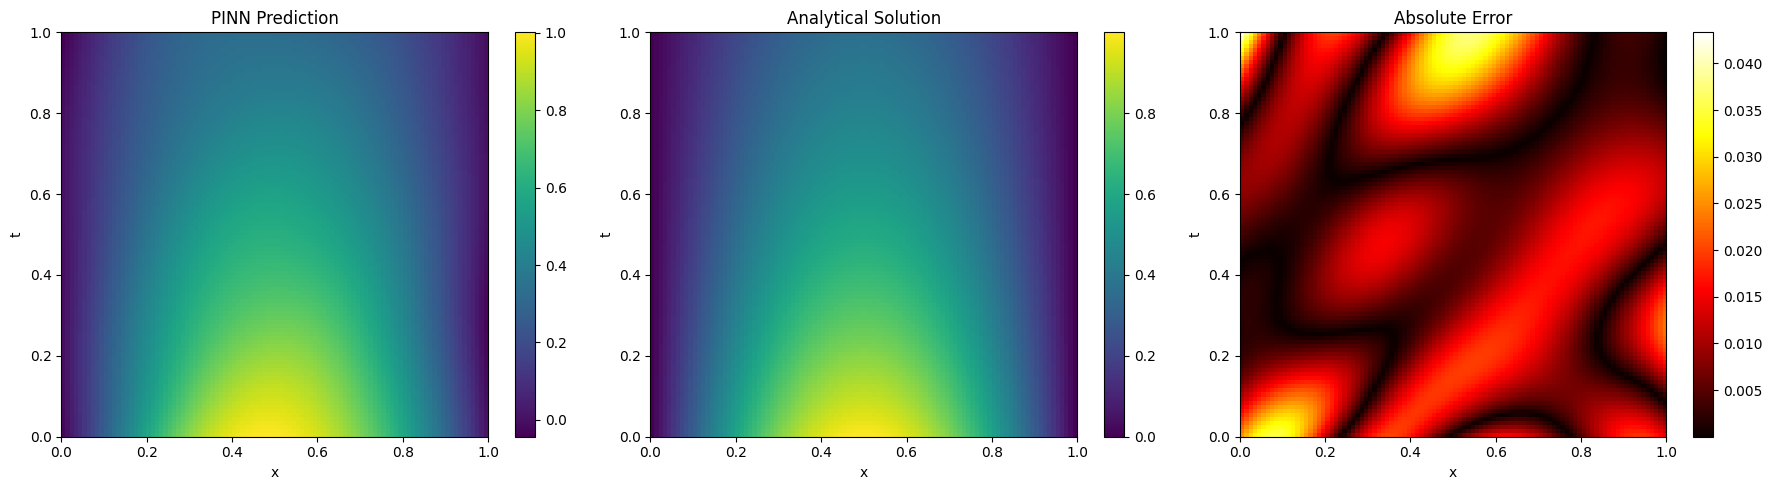

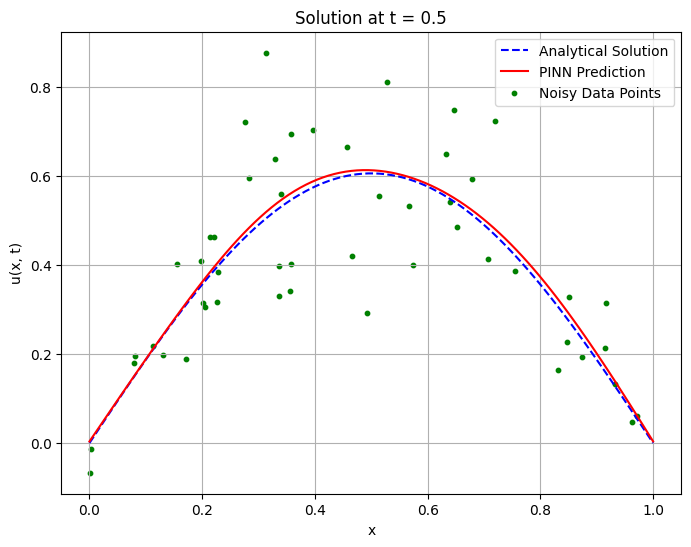

In [8]:
# Create a grid for plotting the solution
x_plot = torch.linspace(0, 1, 100).view(-1, 1)
t_plot = torch.linspace(0, 1, 100).view(-1, 1)
X_plot, T_plot = torch.meshgrid(x_plot.squeeze(), t_plot.squeeze(), indexing='ij')
x_flat = X_plot.reshape(-1, 1)
t_flat = T_plot.reshape(-1, 1)

# Predict with the trained PINN
pinn_model.eval()
with torch.no_grad():
    u_pred_flat = pinn_model(x_flat, t_flat)
    u_pred_grid = u_pred_flat.reshape(100, 100).cpu().numpy()

# Get analytical solution for comparison
u_analytical_grid = u_analytical(X_plot, T_plot, alpha=alpha_val).cpu().numpy()

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PINN Prediction
im1 = axes[0].imshow(u_pred_grid.T, extent=[0, 1, 0, 1], origin='lower', cmap='viridis', aspect='auto')
axes[0].set_title('PINN Prediction')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(im1, ax=axes[0])

# Analytical Solution
im2 = axes[1].imshow(u_analytical_grid.T, extent=[0, 1, 0, 1], origin='lower', cmap='viridis', aspect='auto')
axes[1].set_title('Analytical Solution')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
fig.colorbar(im2, ax=axes[1])

# Absolute Error
im3 = axes[2].imshow(np.abs(u_pred_grid - u_analytical_grid).T, extent=[0, 1, 0, 1], origin='lower', cmap='hot', aspect='auto')
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# Plot a slice at a specific time (e.g., t=0.5)
t_slice = 0.5
x_slice = torch.linspace(0, 1, 100).view(-1, 1)
t_slice_tensor = torch.full_like(x_slice, t_slice)

with torch.no_grad():
    u_pred_slice = pinn_model(x_slice, t_slice_tensor).cpu().numpy()
u_analytical_slice = u_analytical(x_slice, t_slice_tensor, alpha=alpha_val).cpu().numpy()

plt.figure(figsize=(8, 6))
plt.plot(x_slice.numpy(), u_analytical_slice, label='Analytical Solution', linestyle='--', color='blue')
plt.plot(x_slice.numpy(), u_pred_slice, label='PINN Prediction', color='red')
plt.scatter(x_data.numpy(), u_data_noisy.numpy(), color='green', marker='o', s=10, label='Noisy Data Points')
plt.title(f'Solution at t = {t_slice}')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid(True)
plt.show()